Modules Imported successfully..
DataFrame Created Successfull...
Dataset is : 
     sepal length (cm)  sepal width (cm)  petal length (cm)  petal width (cm)
0                  5.1               3.5                1.4               0.2
1                  4.9               3.0                1.4               0.2
2                  4.7               3.2                1.3               0.2
3                  4.6               3.1                1.5               0.2
4                  5.0               3.6                1.4               0.2
..                 ...               ...                ...               ...
145                6.7               3.0                5.2               2.3
146                6.3               2.5                5.0               1.9
147                6.5               3.0                5.2               2.0
148                6.2               3.4                5.4               2.3
149                5.9               3.0                5.1    

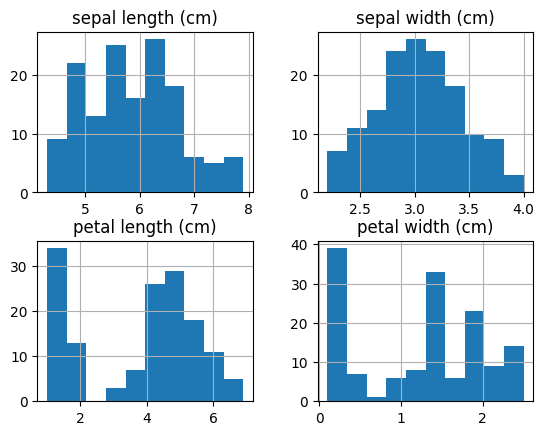

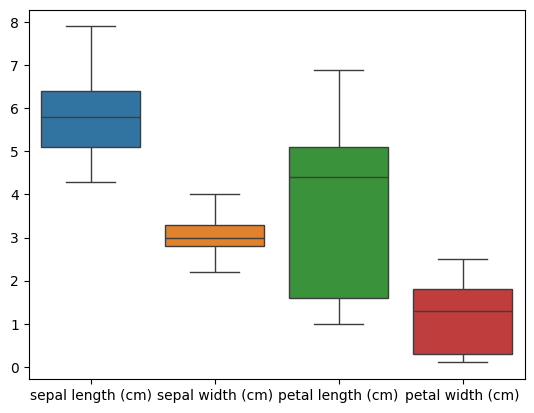

------------------------------------------

visual outcomes for the Z-Score method


AttributeError: 'DataFrame' object has no attribute 'show'

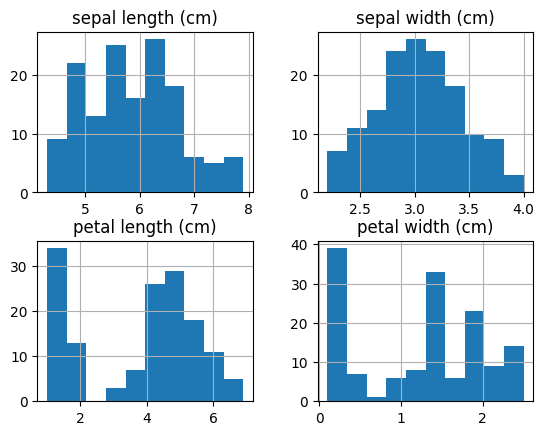

In [3]:
# Implement and compare the outcome of any two methods of outlier detection

# demeonstrate the outlier detection technique

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn import datasets

print('Modules Imported successfully..')

# load the data

data = datasets.load_iris()

# create data frame 
df = pd.DataFrame(data.data, columns=data.feature_names)
print('DataFrame Created Successfull...')

# preprocessing

print('Dataset is : ')
print(df)
print()
print('Information about Dataset is : ')
print(df.info())
print()
print("rows and columns in dataset are : ",df.shape)
print()
print('all null records in the dataset are : ', pd.isnull(df).sum())
print()
df.fillna(0)
print(df.head(10))
print("columns in the dataset are : ",df.columns)
print()
print('duplicated records are : ', df.duplicated())
print()
print('correlation is : ', df.corr())
df.columns
print('-------------------------------')
print('outlier detection')

# 1. IQR Method

Q1 = df.quantile(0.25)
Q3 = df.quantile(0.75)
IQR = Q3 - Q1
df = df[~((df < Q1 - 1.5 * IQR) | (df > Q3 + 1.5 * IQR)).any(axis=1)]
print('outliers are : ', df)

print('---------------------------------------------------')
# 2. Z-Score 
z = np.abs((df-df.mean()) / df.std())
df2 = df[(z<3).all(axis=1)]

print('results of outlier detection are ')
print()
print('1. IQR Method')
print(df)
print('---------------------------------------------')
print('2. Z-Score Method')
print(df2)
print('---------------------------------------------')

print('outliers visuals are : ')
# visualization 
print('visual outcomes for the IQR method')
df.hist()
plt.show()

sns.boxplot(data=df)
plt.show()

print('------------------------------------------')
print()
print('visual outcomes for the Z-Score method')
df2.hist()
df2.show()
sns.boxplot(data=df2)
plt.show()